# 3.55 Pointed -- VIS and NIR Photometric Sensitivity

OVERVIEW: Observe 5 photometric standard stars in order to determine the photometric sensitivity of the VIS and NIR instruments. 

DATA PRODUCTS: 
- This data will be used to estimate the photometric sensitivty of the VIS and NIR instruments.


EXIT CRITERIA: observation obtained, analysis complete and summarized in 3.55_ResultsSummary.md
- Data with a VIS S/N of TBD on 5 stars
- Data with a NIR S/N of TBD on 5 stars


DATA VOLUME: 5 observations, simultaneous VIS and NIR, 9 50x50 VIS regions, 1 84x400 NIR region. Each observation has the same set up, pointed at a different target. 


TARGET CRITERIA: Stars of moderate brightness with well studied spectra. Ideally farther away from the Earth, Moon, and other bright sources than the nominal keep out ranges.


KEY STAKEHOLDERS: Christina Hedges and Tom Barclay


## Load in 

In [1]:
''' Make sure you have pandorasim installed and updated '''
import pandorasat as ps
import pandorasim as pp
# ps.utils.get_phoenix_model(teff=7000, jmag=10) ### this is a temporary fix to an import error with pandorasim
ps.phoenix.get_phoenix_model(6000, jmag=10)
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta
import matplotlib.patches as patches

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR, NIR_ra_shape, NIR_dec_shape, VIS_ra_shape, VIS_dec_shape


## Data Volume

5 observations for 5 different standard stars. Simultaneous VIS and NIR. The observing set up is the same for all 5 observations.

In [2]:
num_observations = 5

In [3]:
##### VIS Observations #####
frames_per_int_VIS      = 50
regions_VIS             = 9
VIS_xpix                = 50
VIS_ypix                = 50
num_int_VIS             = 2400
bits_per_int_VIS        = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS  = frame_time_VIS * frames_per_int_VIS
bits_per_sec_VIS        = bits_per_int_VIS / int_and_reset_time_VIS
bits_per_sec_comp_VIS   = bits_per_sec_VIS / compression_fractor_VIS
test_time_VIS           = num_int_VIS * int_and_reset_time_VIS
bits_test_total_VIS     = bits_per_sec_comp_VIS * test_time_VIS
Gbits_test_packet_VIS   = bits_test_total_VIS / 1E9 * 1.1 * 1.25
downlinks_VIS           = Gbits_test_packet_VIS * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('All VIS Observations:', Gbits_test_packet_VIS*num_observations, 'Gbits')


All VIS Observations: 4.752000000000001 Gbits


In [4]:
##### NIR Observations #####
NIR_xpix                   = 80
NIR_ypix                   = 400
NIR_ROI_StartX             = 1968
NIR_ROI_StartY             = 824
NIR_ROI_SizeX              = 80
NIR_ROI_SizeY              = 400
frames_per_int_NIR         = 19
stored_frames_per_int_NIR  = 2
num_int_NIR                = 3417
frame_time_NIR             = (NIR_xpix+12) * (NIR_ypix+2) * 0.00001 #sec
int_and_reset_time_NIR     = frame_time_NIR * (frames_per_int_NIR+1)
bits_per_int_NIR           = NIR_xpix * NIR_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR
bits_per_sec_NIR           = bits_per_int_NIR / int_and_reset_time_NIR
test_time_NIR              = num_int_NIR * int_and_reset_time_NIR
bits_per_sec_comp_NIR      = bits_per_sec_NIR / compression_fractor_NIR
bits_test_total_NIR        = bits_per_sec_comp_NIR * test_time_NIR
Gbits_test_packet_NIR      = bits_test_total_NIR / 1E9 * 1.1 * 1.25
downlinks_NIR              = Gbits_test_packet_NIR * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('All NIR Observations:', Gbits_test_packet_NIR*num_observations, 'Gbits')
observing_time = 6.67*3600 #sec
NIR_SC_Integrations = observing_time / (frames_per_int_NIR * frame_time_NIR) #dimensionless
round(NIR_SC_Integrations)

All NIR Observations: 14.433408 Gbits


3417

### Total Data Volume

In [5]:
Gbits_total = (Gbits_test_packet_VIS + Gbits_test_packet_NIR) * num_observations
downlinks_total = (downlinks_VIS + downlinks_NIR) * num_observations
test_time_total = np.max([test_time_VIS, test_time_NIR]) * num_observations

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 35.10398 hours
Volume, total: 19.185408000000002 Gbits
Downlinks, total: 7.993920000000001


## Define 5 Targets

In [6]:
### Possible Targets:
# ...
# ...
# ...
# ...
# ...
# ...
# ...
# ...

In [ ]:
Targets = ["HD_38949", "HD_284248", "HD_60753", "HD_37962", "HD_37725"]  

## The rest of this notebook should be run for each of the 5 targets. Select an observation number

In [ ]:
observation_number = 4
target = Targets[observation_number]

In [9]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
c = SkyCoord.from_name(target)


''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(test_time_VIS, test_time_NIR)
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
simVIS = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions_VIS) 
simNIR = NIRSim() 


''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
theta0     = 0*u.deg
simVIS.point(c.ra, c.dec, theta0)
simNIR.point(c.ra, c.dec, theta0)

Output()

Output()

Output()

Output()

Output()

...

2025-09-18 17:43:20 WARNING: 0.0K source in catalog is not modelable. Setting to 2000K.

2025-09-18 17:43:20 WARNING: 0.0K source in catalog is not modelable. Setting to 2000K.

2025-09-18 17:43:22 WARNING: 0.0K source in catalog is not modelable. Setting to 2000K.

2025-09-18 17:43:22 WARNING: 0.0K source in catalog is not modelable. Setting to 2000K.

Output()

## Generate Simulated Observation

### VIS Observation

<Axes: title={'center': 'VISDA\n(RA:85.48 deg, Dec:29.30 deg, Roll:0.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

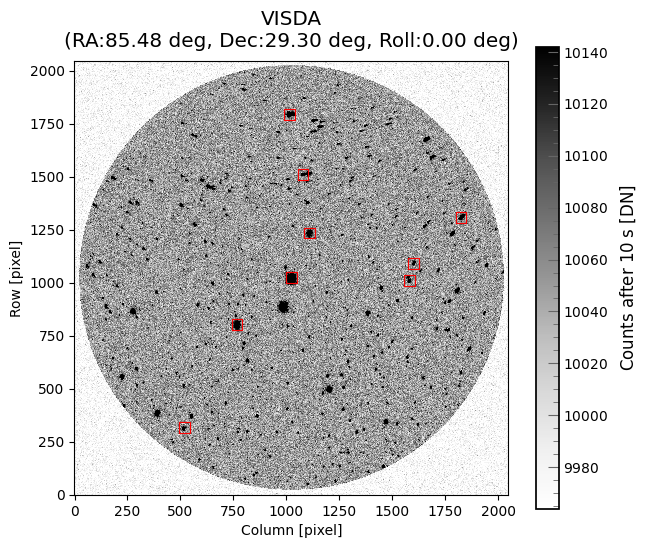

In [10]:
''' Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays. '''
simVIS.show_FFI()

In [11]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

### reduce the number of integrations to speed up calculations
reduction = 100 # set to 1 for no reduction
data = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(num_int_VIS/reduction), start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|███████████████████████████████████████| 21/21 [00:01<00:00, 14.62it/s]


(9, 24, 50, 50)

### NIR Observation

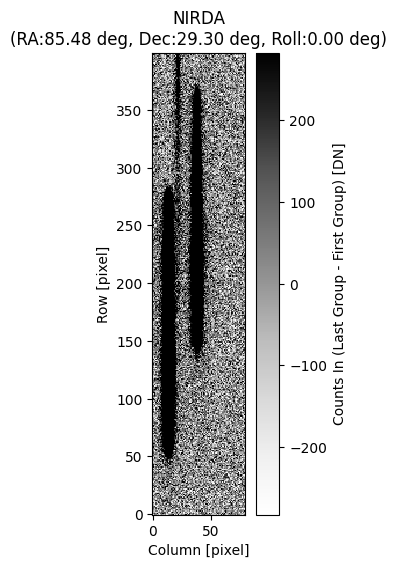

In [12]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [13]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted
# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

data = simNIR.observe(SC_Integrations=int(num_int_NIR/reduction), SC_ReadFrames=stored_frames_per_int_NIR, start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████████████████████████████| 8/8 [02:50<00:00, 21.26s/it]


(34, 2, 400, 80)

## Save the Simulated Observation

In [14]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist_vis = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(num_int_VIS/reduction), start_time=start_time)
hdulist_nir = simNIR.observe(SC_Integrations=int(num_int_NIR/reduction), SC_ReadFrames=stored_frames_per_int_NIR, start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.55_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.55_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

Modeling Pixel Positions: 100%|█████████████████████████████████████████| 9/9 [02:28<00:00, 16.51s/it]


In [15]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

Filename: 3.55_VISrois_HD37725_obs4.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  SCIENCE       1 ImageHDU        71   (150, 150, 24)   int64   
  2  ROITABLE      1 BinTableHDU     36   2R x 9C   [D, K, K, K, K, K, K, K, K]   
None


## Data Products

### This data will be used to estimate the photometric sensitivty of the VIS and NIR instruments.

## Generate SOC File

In [ ]:
### Select which target to observe (include if skipping the simulation step above)
obs = 4
target = Targets[obs]

### Finds target coordinates based on astropy
### You can do this differently as long as you have DEC and RA
c = SkyCoord.from_name(target)
ras = [87.0834300765, 63.6500275460, 113.3638074910, 85.2162142588, 85.4766170307]
decs = [-24.4640056808, 22.3498409821, -50.5842294716, -31.3527301875, 29.2973683706]
pmra = [-30.321789497327995, 425.2309965317768, -2.897312343490181, -59.52029065579583, 14.970491295562521]
pmdec = [-35.463902915364415, -301.5641666599744, 5.616557096607084, -365.1467953830785, -26.791844195438347]
plx = [22.45410149717266, 11.37834552896058, 1.4718660108263308, 28.57913690491284, 6.260719470774169]
rv = [3.3774827, 0, 0, 3.0999413, 13.776083]

roi_ras = [
    [87.1378442681438, 86.98500755729762, 86.92644853251187, 86.92960520350267, 87.34704625368744, 87.34774219194658, 86.80798722510778, 87.33816263107846],
    [63.70586103270341, 63.62719024637831, 63.720581532032774, 63.78787496200373, 63.64923035532877, 63.4816110098284, 63.44832226934307, 63.75492148713149],
    [113.45177148445235, 113.50348273635956, 113.57131799156726, 113.5950336700528, 113.27214108159188, 113.07328963501308, 113.55189624457621, 113.21915695350131],
    [85.20424144617992, 85.24886299130179, 85.09467338671719, 85.29477726301319, 85.1671794575365, 85.24041771403186, 85.43334524845177, 85.02665508051783],
    [85.48593112596299, 85.45546153264924, 85.53999421390706, 85.4318454372885, 85.4784893969843, 85.33748042653758, 85.64618478365207, 85.49734190136245]
]
roi_decs = [
    [-24.40799131818154, -24.38488737863343, -24.437539982562154, -24.410656869379824, -24.460588959688668, -24.460294669644174, -24.4939255459669, -24.36372230613321],
    [22.30297114779247, 22.451724807607018, 22.463168004579867, 22.39337639419342, 22.156251392246812, 22.224354959852008, 22.234848617564275, 22.14361952193322],
    [-50.52581827225321, -50.647727971654966, -50.53681824216776, -50.618449705976076, -50.76363712669955, -50.54091043193416, -50.75097233333335, -50.79281492748383],
    [-31.4020348761324, -31.430958328242202, -31.38314212257112, -31.229657214926384, -31.20127390523, -31.520171800396213, -31.313033617162265, -31.245823158913716],
    [29.268205601447534, 29.3434249686205, 29.250346285666538, 29.184920048878357, 29.466591891977252, 29.48729728562911, 29.126682765329008, 29.522620927554325]
]

### Identify the start time and end time of the observation
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(test_time_VIS, test_time_NIR)
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta

c = SkyCoord(
    ra=ras[obs]*u.deg,
    dec=decs[obs]*u.deg,
    pm_ra_cosdec=pmra[obs]*u.mas/u.year,
    pm_dec=pmdec[obs]*u.mas/u.year,
    obstime=Time.strptime("2016", "%Y"),
    distance=Distance(parallax=plx[obs] * u.mas, allow_negative=True),
    radial_velocity=rv[obs]*u.km/u.s
).apply_space_motion(start_time)

roi_ras[obs].insert(0, c.ra.value)
roi_decs[obs].insert(0, c.dec.value)


In [ ]:
'Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 
### This is not all correct! Revisit and check once notebook is complete. 

variables = {
    'visit_id': '0355', ### setting based on task number. Could change. 
    'obs_id': f"{obs:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time.strftime('%Y-%m-%dT%H:%M:%SZ'), 
    'stop_time': end_time.strftime('%Y-%m-%dT%H:%M:%SZ'), 
    'RA': c.ra.value,
    'DEC': c.dec.value, 
    'ffi_flag':0,
    
    'NIR_AvgGroups': 1, ### 1 if Fowler sampling, 0 if keeping every frame 
    'NIR_ROI_StartX': NIR_ROI_StartX, 
    'NIR_ROI_StartY': NIR_ROI_StartY, 
    'NIR_ROI_SizeX': NIR_ROI_SizeX, 
    'NIR_ROI_SizeY': NIR_ROI_SizeY,
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 16,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': stored_frames_per_int_NIR/2,#frames_per_int_NIR,
    'NIR_targetID': target, 
    'NIR_SC_Groups': 2,
    'NIR_SC_Integrations': round(NIR_SC_Integrations),  
    
    'VIS_StarRoiDetMethod': 1,  ### 1: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 2: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': frames_per_int_VIS, 
    'VIS_NumTotalFramesRequested': frames_per_int_VIS * num_int_VIS, #GO OVER THIS
    'VIS_TargetRA': c.ra.value, 
    'VIS_TargetDEC': c.dec.value, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
    'VIS_MaxNumStarRois': 9, ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': 9, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': roi_ras[obs], ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': roi_decs[obs], 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': 1, 
    'VIS_ExposureTime_us': int(frame_time_VIS * 1000000)
}

In [21]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_SOC.xml' 
generate_task_plan(variables, output_soc_file)